In [ ]:
# Install library (jalankan di Colab)
!pip install lightgbm xgboost imbalanced-learn kaggle


In [9]:
from google.colab import files
files.upload()  # upload kaggle.json


Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"hildaarifin","key":"d3477a3eb8a7e43da3cfb086837324d9"}'}

In [14]:
!ls


'kaggle (2).json'   sample_data


In [16]:
!mkdir -p ~/.kaggle


In [17]:
!cp "kaggle (2).json" ~/.kaggle/kaggle.json


In [18]:
!chmod 600 ~/.kaggle/kaggle.json


In [19]:
!kaggle datasets list


ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
wardabilal/spotify-global-music-dataset-20092025                   Spotify Global Music Dataset (2009–2025)               1289021  2025-11-11 09:43:05.933000          14038        315  1.0              
rohiteng/spotify-music-analytics-dataset-20152025                  Spotify Music Analytics Dataset (2015–2025)            5080400  2025-12-04 05:17:45.537000           1541         37  1.0              
neurocipher/heartdisease                                           Heart Disease                                             3491  2025-12-11 15:29:14.327000            823         24  1.0

In [20]:
!kaggle datasets download -d abdulwadood11220/netflix-customer-churn-dataset
!unzip netflix-customer-churn-dataset.zip


Dataset URL: https://www.kaggle.com/datasets/abdulwadood11220/netflix-customer-churn-dataset
License(s): CC-BY-SA-4.0
  0% 0.00/186k [00:00<?, ?B/s]
100% 186k/186k [00:00<00:00, 598MB/s]
Archive:  netflix-customer-churn-dataset.zip
  inflating: netflix_customer_churn.csv  


In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")


In [22]:
df = pd.read_csv("netflix_customer_churn.csv")
df.head()


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

*PREPROCESSING DATA


In [24]:
# Drop kolom ID (tidak dipakai untuk prediksi)
df = df.drop(columns=["customer_id"])

# Target
y = df["churned"]

# Fitur
X = df.drop(columns=["churned"])


In [25]:
df.isnull().sum()


,0
age,0
gender,0
subscription_type,0
watch_hours,0
last_login_days,0
region,0
device,0
monthly_fee,0
churned,0
payment_method,0


In [26]:
#encoding
cat_cols = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre"
]


In [27]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
for col in cat_cols:
    X[col] = encoder.fit_transform(X[col])


In [28]:
#scaling data
num_cols = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]



In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [30]:
#split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)


In [31]:
#SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())
print(y_train_sm.value_counts())


churned
1    2138
0    2112
Name: count, dtype: int64
churned
1    2138
0    2138
Name: count, dtype: int64


**XGBOOST

In [32]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

xgb_model.fit(X_train_sm, y_train_sm)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
from sklearn.metrics import classification_report
import pandas as pd

report_xgb = classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Tidak Churn", "Churn"],
    output_dict=True
)

df_report_xgb = pd.DataFrame(report_xgb).transpose()
df_report_xgb


,precision,recall,f1-score,support
Tidak Churn,0.986702,0.994638,0.990654,373.000000
Churn,0.994652,0.986737,0.990679,377.000000
accuracy,0.990667,0.990667,0.990667,0.990667
macro avg,0.990677,0.990688,0.990667,750.000000
weighted avg,0.990698,0.990667,0.990667,750.000000


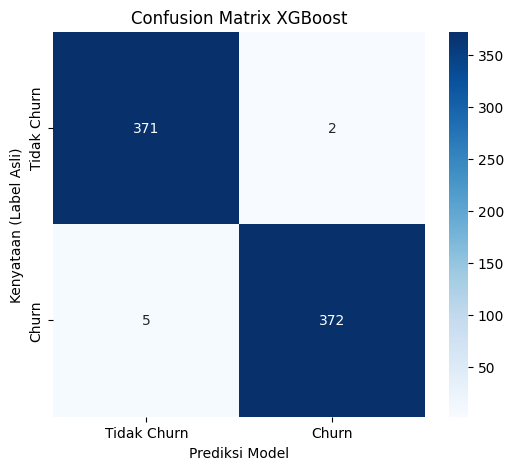

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak Churn", "Churn"],
    yticklabels=["Tidak Churn", "Churn"]
)

plt.xlabel("Prediksi Model")
plt.ylabel("Kenyataan (Label Asli)")
plt.title("Confusion Matrix XGBoost")
plt.show()


LIGHTGBM


In [41]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train_sm, y_train_sm)

y_pred_lgb = lgb_model.predict(X_test)
y_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]


[LightGBM] [Info] Number of positive: 2138, number of negative: 2138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 4276, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [51]:
report_lgb = classification_report(
    y_test,
    y_pred_lgb,
    target_names=["Tidak Churn", "Churn"],
    output_dict=True
)

pd.DataFrame(report_lgb).transpose()


,precision,recall,f1-score,support
Tidak Churn,0.984043,0.991957,0.987984,373.000
Churn,0.991979,0.984085,0.988016,377.000
accuracy,0.988000,0.988000,0.988000,0.988
macro avg,0.988011,0.988021,0.988000,750.000
weighted avg,0.988032,0.988000,0.988000,750.000


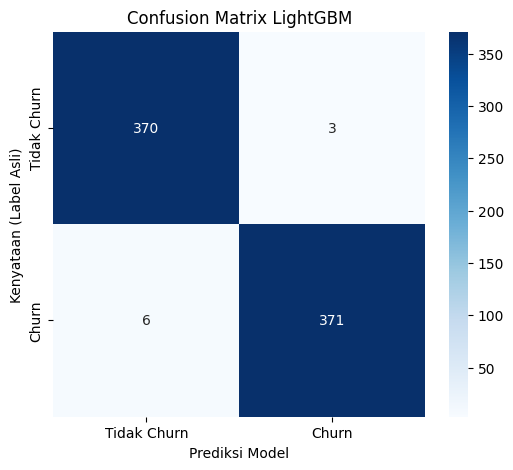

In [49]:
cm_lgb = confusion_matrix(y_test, y_pred_lgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak Churn", "Churn"],
    yticklabels=["Tidak Churn", "Churn"]
)

plt.xlabel("Prediksi Model")
plt.ylabel("Kenyataan (Label Asli)")
plt.title("Confusion Matrix LightGBM")
plt.show()


PERBANDINGAN

In [55]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
import pandas as pd

results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],

    "Accuracy": [
        accuracy_score(y_test, xgb_model.predict(X_test)),
        accuracy_score(y_test, lgb_model.predict(X_test))
    ],

    "Precision": [
        precision_score(y_test, xgb_model.predict(X_test)),
        precision_score(y_test, lgb_model.predict(X_test))
    ],

    "Recall": [
        recall_score(y_test, xgb_model.predict(X_test)),
        recall_score(y_test, lgb_model.predict(X_test))
    ],

    "F1-Score": [
        f1_score(y_test, xgb_model.predict(X_test)),
        f1_score(y_test, lgb_model.predict(X_test))
    ],

    "AUC": [
        roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1])
    ]
})

results


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,XGBoost,0.990667,0.994652,0.986737,0.990679,0.998194
1,LightGBM,0.988000,0.991979,0.984085,0.988016,0.998919


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_test, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

results = {
    "XGBoost": evaluate_model(y_test, y_pred_xgb, y_proba_xgb),
    "LightGBM": evaluate_model(y_test, y_pred_lgb, y_proba_lgb)
}

results


{'XGBoost': {'Accuracy': 0.9906666666666667,
  'Precision': 0.9946524064171123,
  'Recall': 0.986737400530504,
  'F1-Score': 0.9906790945406125,
  'AUC': np.float64(0.9981937263993287)},
 'LightGBM': {'Accuracy': 0.988,
  'Precision': 0.9919786096256684,
  'Recall': 0.9840848806366048,
  'F1-Score': 0.9880159786950732,
  'AUC': np.float64(0.9989190803649526)}}

In [53]:
hasil_prediksi = X_test.copy()

hasil_prediksi["Aktual_Churn"] = y_test.values
hasil_prediksi["Prediksi_Churn_XGBoost"] = y_pred_xgb
hasil_prediksi["Prob_Churn_XGBoost"] = y_proba_xgb

hasil_prediksi["Prediksi_Churn_LightGBM"] = y_pred_lgb
hasil_prediksi["Prob_Churn_LightGBM"] = y_proba_lgb

hasil_prediksi.head(5)


,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,Aktual_Churn,Prediksi_Churn_XGBoost,Prob_Churn_XGBoost,Prediksi_Churn_LightGBM,Prob_Churn_LightGBM
3652,0.365385,0,2,0.106803,0.383333,0,1,0.555556,2,0.50,0.004979,1,0,0,0.000491,0,0.000330
1006,0.384615,1,2,0.010871,0.350000,5,3,0.555556,4,0.75,0.000610,5,0,0,0.022791,0,0.001882
2528,0.384615,2,0,0.038500,0.700000,2,2,0.000000,3,1.00,0.001016,0,1,1,0.999968,1,0.999999
2767,0.423077,2,2,0.116043,0.600000,1,3,0.555556,0,0.25,0.003556,5,1,1,0.986022,1,0.999239
2781,0.076923,0,2,0.093124,0.283333,5,0,0.555556,3,1.00,0.005792,1,0,0,0.000137,0,0.000004
